In [ ]:
import os
import sys
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms, models
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 7
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Using device: cpu


In [ ]:
# extract and process data

ROOT = Path("/Users/arushi/Documents/Final-project-ECE-49595CV/urban-street_-tree-classification-DatasetNinja").resolve().parent

if not ROOT.exists():
    print(f"WARNING: Dataset not found at {ROOT}.")

train_dir = ROOT / "urban-street_-tree-classification-DatasetNinja" / "train" / "img"
test_dir = ROOT / "urban-street_-tree-classification-DatasetNinja" / "test" / "img"
val_dir = ROOT / "urban-street_-tree-classification-DatasetNinja" / "val" / "img"

# image settings
image_size = (224, 224) 

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),        # resize
    transforms.RandomResizedCrop(224),    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),        # 15 rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet stats
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# data loading

folders = {
    "Acer palmatum": 0, "Cedrus deodara": 1, "Celtis sinensis": 2, 
    "Cinnamomum camphora (Linn) Presl": 3, "Elaeocarpus decipiens": 4, 
    "Flowering cherry": 5, "Ginkgo biloba": 6, "Koelreuteria paniculata": 7,
    "IMG": 8, "Lagerstroemia indica": 8, "Liquidambar formosana": 9, 
    "Liriodendron chinense": 10, "Magnolia grandiflora L": 11, 
    "Magnolia liliflora Desr": 12, "Michelia chapensis": 13, 
    "Osmanthus fragrans": 14, "Photinia serratifolia": 15, "Platanus": 16, 
    "Prunus cerasifera f. atropurpurea": 17, "Salix babylonica": 18, 
    "Sapindus saponaria": 19, "Styphnolobium japonicum": 20, 
    "Triadica sebifera": 21, "Zelkova serrata": 22
}

def load_data(directory, transform):
    imgs = []
    labs = []
    
    if not directory.exists():
        print(f"Directory not found: {directory}")
        return torch.empty(0), torch.empty(0)
        
    print(f"Loading data from {directory}...")
    for filename in os.listdir(directory):
        if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
            
        try:
            class_key = filename.split("_")[0]
            if class_key in folders:
                img = Image.open(directory / filename).convert("RGB")
                img = transform(img)
                imgs.append(img)
                labs.append(folders[class_key])
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            
    if len(imgs) == 0:
        print(f"No images found in {directory} matching the classes.")
        return torch.empty(0), torch.empty(0)

    return torch.stack(imgs), torch.tensor(labs)

X_train, Y_train = load_data(train_dir, train_transform)
X_val, Y_val = load_data(val_dir, val_test_transform)
X_test, Y_test = load_data(test_dir, val_test_transform)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

batch_size = 32 

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=batch_size, shuffle=False)

Loading data from /Users/arushi/Documents/Final-project-ECE-49595CV/urban-street_-tree-classification-DatasetNinja/train/img...
Loading data from /Users/arushi/Documents/Final-project-ECE-49595CV/urban-street_-tree-classification-DatasetNinja/val/img...
Loading data from /Users/arushi/Documents/Final-project-ECE-49595CV/urban-street_-tree-classification-DatasetNinja/test/img...
Training samples: 3850
Validation samples: 482
Test samples: 472


In [ ]:
# resnet transfer learning

def get_model(num_classes):
    # load resnet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # num features
    num_ftrs = model.fc.in_features
    
    #replace last layer
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model.to(device)

model = get_model(num_classes=23)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
# smaller learning rate for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/arushi/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 32.4MB/s]


In [ ]:
# training loop

def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0  # init as int

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            if phase == 'train':
                scheduler.step()

            dataset_size = len(dataloader.dataset) # type: ignore
            
            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects / dataset_size

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), "best_tree_model.pth")
                print(f"--> New Best Model Saved (Acc: {best_acc:.4f})")

    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

# train
model = train_model(model, criterion, optimizer, scheduler, num_epochs=20)

Epoch 1/20
----------
train Loss: 1.6623 Acc: 0.5621
val Loss: 1.0176 Acc: 0.6971
--> New Best Model Saved (Acc: 0.6971)
Epoch 2/20
----------
train Loss: 0.6720 Acc: 0.8543
val Loss: 0.8428 Acc: 0.7718
--> New Best Model Saved (Acc: 0.7718)
Epoch 3/20
----------
train Loss: 0.2123 Acc: 0.9803
val Loss: 0.6878 Acc: 0.8195
--> New Best Model Saved (Acc: 0.8195)
Epoch 4/20
----------
train Loss: 0.0706 Acc: 0.9979
val Loss: 0.6482 Acc: 0.8257
--> New Best Model Saved (Acc: 0.8257)
Epoch 5/20
----------
train Loss: 0.0340 Acc: 0.9997
val Loss: 0.6350 Acc: 0.8320
--> New Best Model Saved (Acc: 0.8320)
Epoch 6/20
----------
train Loss: 0.0199 Acc: 0.9997
val Loss: 0.6131 Acc: 0.8320
Epoch 7/20
----------
train Loss: 0.0148 Acc: 0.9997
val Loss: 0.6300 Acc: 0.8340
--> New Best Model Saved (Acc: 0.8340)
Epoch 8/20
----------
train Loss: 0.0100 Acc: 1.0000
val Loss: 0.6263 Acc: 0.8320
Epoch 9/20
----------
train Loss: 0.0097 Acc: 1.0000
val Loss: 0.6135 Acc: 0.8237
Epoch 10/20
----------
train

In [ ]:
# evaluation

def evaluate_test(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    
    return correct / total

test_acc = evaluate_test(model, test_loader)
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.7903


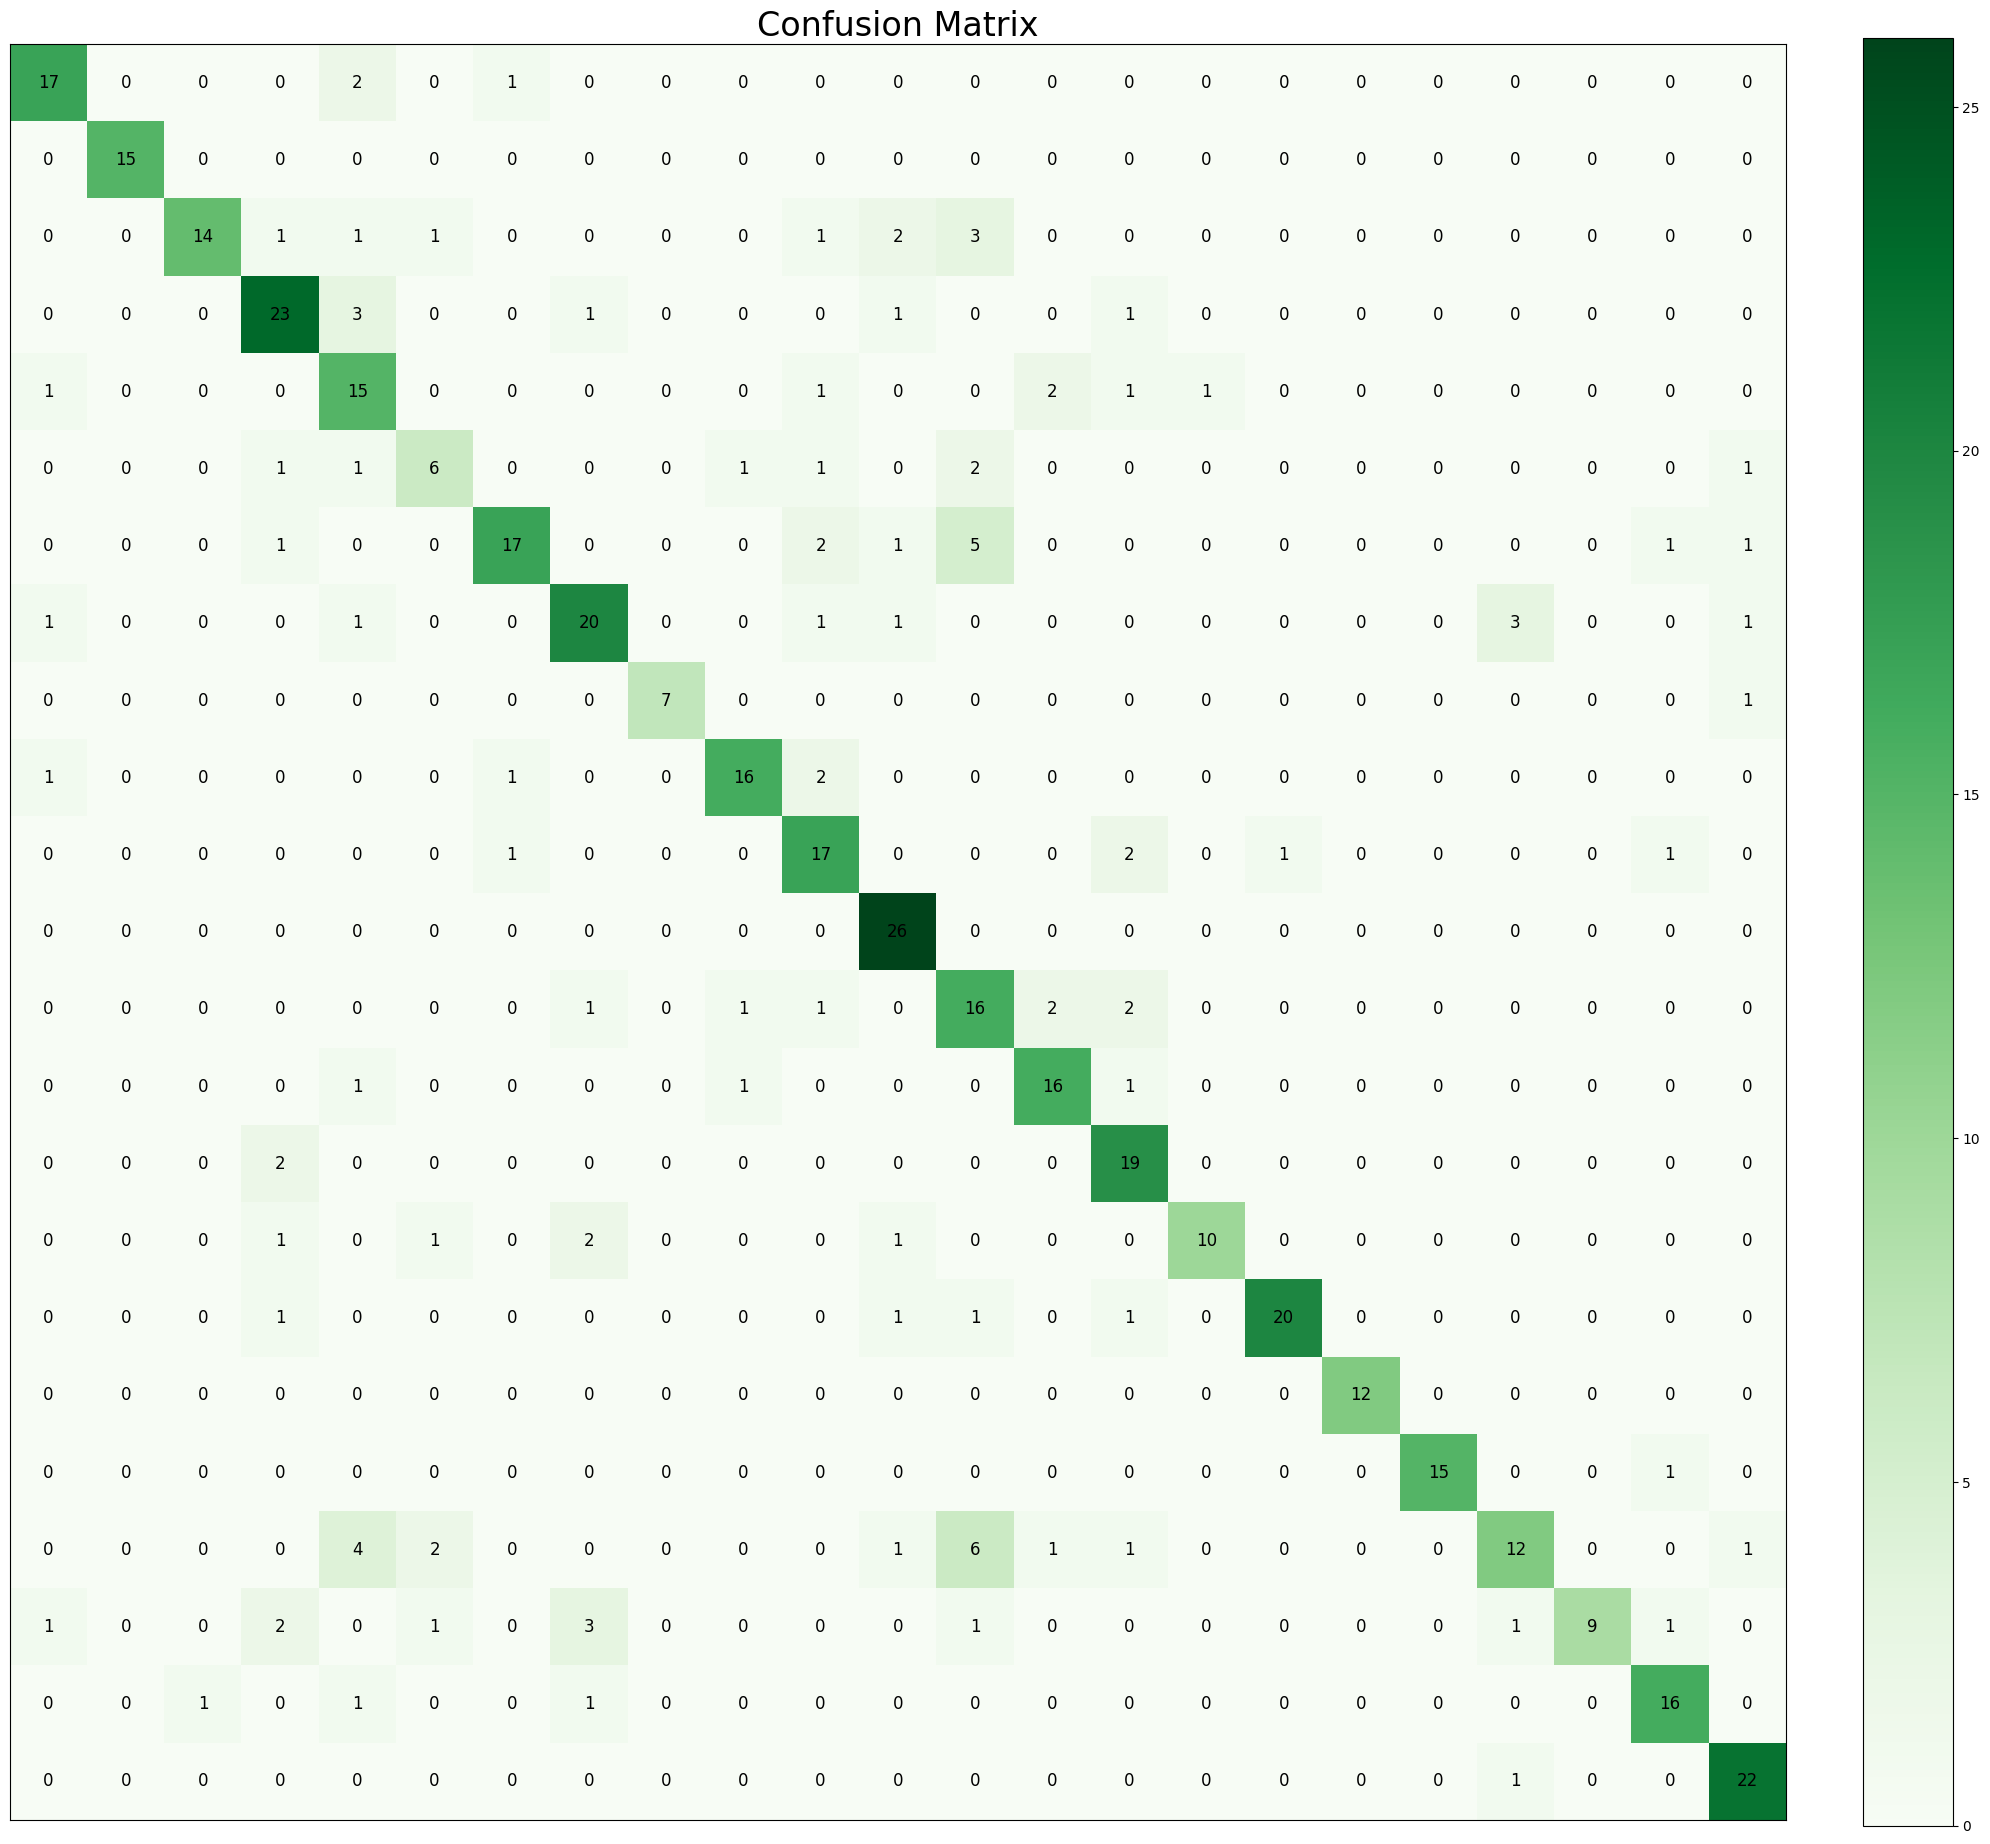

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Collect predictions and labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 20))  # VERY large plot for visibility

# Use a green colormap
plt.imshow(cm, interpolation='nearest', cmap='Greens')

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 fontsize=12, color='black')

# Remove ticks, labels, and clutter
plt.xticks([])
plt.yticks([])
plt.xlabel("")
plt.ylabel("")
plt.title("Confusion Matrix", fontsize=24)

plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
